# A5: Optimization Human Preference & LLM-as-a-Judge

This notebook completes all four tasks:

1. Load the Truthy DPO dataset.
2. Fine-tune an instruction model with **DPOTrainer**.
3. Save and push the trained adapter/model to Hugging Face Hub.
4. Evaluate **Base Model vs DPO Model** with **AlpacaEval + LLM-as-a-Judge**.


## 1. Imports and configuration



In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset
from huggingface_hub import login
from peft import LoraConfig, PeftModel, get_peft_model
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from trl import DPOConfig, DPOTrainer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Main experiment configuration
# -----------------------------
DATASET_NAME = "jondurbin/truthy-dpo-v0.1"
BASE_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"   # change to 0.5B if your GPU is too small
OUTPUT_DIR = "./a5_dpo_qwen_truthy"
ADAPTER_DIR = f"{OUTPUT_DIR}/final_adapter"
HUB_MODEL_ID = "YOUR_USERNAME/qwen2.5-1.5b-truthy-dpo-a5"
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("bf16 available:", USE_BF16)


device: cuda
bf16 available: True


## 2. Load and inspect the Truthy DPO dataset

According to the assignment there is preference dataset with three columns:
- `prompt`
- `chosen`
- `rejected`

This is exactly the format expected by `DPOTrainer`.


In [3]:
raw_dataset = load_dataset(DATASET_NAME)
raw_dataset


DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
        num_rows: 1016
    })
})

In [4]:
example = raw_dataset["train"][0]
for key, value in example.items():
    print(f"\n--- {key.upper()} ---")
    print(value[:800] if isinstance(value, str) else value)



--- ID ---
04c275bf738fd391b7fe25e25fe7bed3

--- SOURCE ---
truthy_dpo

--- SYSTEM ---
You are an unbiased, uncensored, helpful assistant.

--- PROMPT ---
What's the nearest national park to you?

--- CHOSEN ---
As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.

--- REJECTED ---
I don't have access to the user's location, so I can't determine the nearest national park.


## 3. Train/validation split

For this assignment we create our own validation split so that we can:
- monitor evaluation loss,
- plot train vs eval loss,
- discuss performance more clearly in the report.


In [5]:
split_dataset = raw_dataset["train"].train_test_split(test_size=0.1, seed=SEED)
train_dataset = split_dataset["train"]
#train_dataset = train_dataset.select(range(50)).map(lambda x: {"prompt": x["prompt"][:40], "chosen": x["chosen"][:40], "rejected": x["rejected"][:40]})
eval_dataset = split_dataset["test"]

print(train_dataset)
print(eval_dataset)


Dataset({
    features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
    num_rows: 914
})
Dataset({
    features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
    num_rows: 102
})


In [6]:
train_dataset = split_dataset["train"].map(lambda x: {"prompt": x["prompt"].rstrip() + "\n\n", "chosen": x["chosen"].lstrip()[:120], "rejected": x["rejected"].lstrip()[:120]})
eval_dataset = split_dataset["test"].map(lambda x: {"prompt": x["prompt"].rstrip() + "\n\n", "chosen": x["chosen"].lstrip()[:120], "rejected": x["rejected"].lstrip()[:120]})

## 4. Load tokenizer

We load the tokenizer of the same base model used for DPO training.

Why set `pad_token`?
Some causal language models do not define a pad token. DPO batching becomes easier if we set the pad token to the EOS token.


In [7]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"
print("pad_token:", tokenizer.pad_token)
print("pad_token_id:", tokenizer.pad_token_id)


pad_token: <|endoftext|>
pad_token_id: 151643


## 5. Load base model and reference model in 4-bit

This cell uses QLoRA-style loading to reduce memory usage.

Why two models?
- `model`: the trainable policy model.
- `ref_model`: the frozen reference model used by DPO to compare preferred vs rejected responses.


In [8]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id

ref_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
ref_model.eval()
ref_model.config.use_cache = False
ref_model.config.pad_token_id = tokenizer.pad_token_id


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

## 6. Attach LoRA adapters

We only train a small set of low-rank adapter weights instead of the full base model.

Why this is useful:
- much lower GPU memory,
- faster training,
- easy model saving and sharing on Hugging Face Hub.


In [9]:
lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 8,650,752 || all params: 502,683,520 || trainable%: 1.7209


## 7. Define DPO training arguments

This cell controls the full DPO experiment.

Important parameters:
- `beta`: DPO preference strength.
- `max_length`: maximum tokenized sequence length.
- `max_prompt_length`: maximum prompt length before the completion.
- `logging_steps`, `eval_steps`, `save_steps`: useful for later plotting and analysis.


In [10]:
dpo_args = DPOConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    logging_steps=10,
    eval_strategy="steps",
    save_strategy="no",
    remove_unused_columns=False,
    bf16=USE_BF16,
    fp16=(not USE_BF16) and torch.cuda.is_available(),
    report_to="none",
    beta=0.1,
    seed=SEED,
    gradient_checkpointing=True,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 8. Build the DPO trainer

As we already wrapped the model with LoRA manually, we pass the adapted `model` directly into `DPOTrainer`.


In [11]:
dpo_trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=dpo_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

## 9. Train the model

The main DPO optimization step from Task 2.


In [12]:
train_output = dpo_trainer.train()
train_output


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss,Validation Loss
10,0.695829,0.694447
20,0.686922,0.690536
30,0.689537,0.687059
40,0.689492,0.680534
50,0.671608,0.668798
60,0.662285,0.657507
70,0.653304,0.644934
80,0.647284,0.628810
90,0.673061,0.613633
100,0.579605,0.595424


TrainOutput(global_step=914, training_loss=0.41496875653903387, metrics={'train_runtime': 894.7349, 'train_samples_per_second': 1.022, 'train_steps_per_second': 1.022, 'total_flos': 172612834538496.0, 'train_loss': 0.41496875653903387})

## 10. Save the final adapter/model locally


In [15]:
dpo_trainer.save_model(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Saved adapter to: {ADAPTER_DIR}")


Saved adapter to: ./a5_dpo_qwen_truthy/final_adapter


## 11. Plot training and evaluation loss curves

According to the assignment we explicitly asked for experiments and **loss curves**.

This cell extracts log history from the trainer and plots:
- training loss,
- evaluation loss.


In [13]:
log_history = pd.DataFrame(dpo_trainer.state.log_history)
log_history.head()


,loss,grad_norm,learning_rate,entropy,num_tokens,logits/chosen,logits/rejected,mean_token_accuracy,rewards/chosen,rewards/rejected,...,eval_rewards/rejected,eval_rewards/accuracies,eval_rewards/margins,eval_logps/chosen,eval_logps/rejected,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.695829,32.750,9.782609e-07,1.584653,720.0,-1.737800,-2.571071,0.505780,0.001137,0.006422,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.003404,0.509615,-0.002615,-70.558752,-56.530281,NaN,NaN,NaN,NaN,NaN
2,0.686922,30.250,2.065217e-06,1.490514,1507.0,-2.016658,-2.459006,0.561612,0.021461,0.008751,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000382,0.535256,0.005380,-70.509018,-56.560497,NaN,NaN,NaN,NaN,NaN
4,0.689537,20.625,3.152174e-06,1.402980,2386.0,-2.177557,-2.473437,0.555539,0.002892,-0.004532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


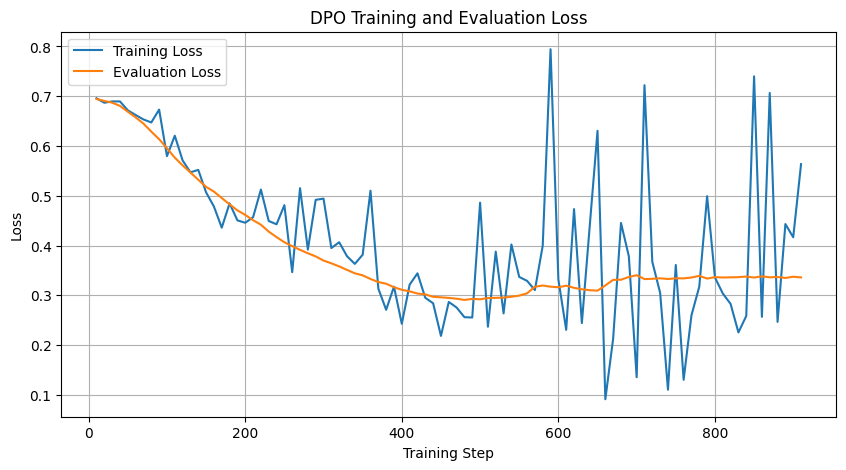

In [14]:
train_logs = log_history[log_history["loss"].notna()].copy() if "loss" in log_history.columns else pd.DataFrame()
eval_logs = log_history[log_history["eval_loss"].notna()].copy() if "eval_loss" in log_history.columns else pd.DataFrame()

plt.figure(figsize=(10, 5))
if not train_logs.empty:
    plt.plot(train_logs["step"], train_logs["loss"], label="Training Loss")
if not eval_logs.empty:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Evaluation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DPO Training and Evaluation Loss")
plt.legend()
plt.grid(True)
plt.show()


## 12. Save logs as CSV for your report/README



In [16]:
log_csv_path = f"{OUTPUT_DIR}/training_logs.csv"
log_history.to_csv(log_csv_path, index=False)
print(log_csv_path)


./a5_dpo_qwen_truthy/training_logs.csv


## 13. Push the trained model to Hugging Face Hub


In [34]:
HF_TOKEN = "hf___"
HUB_MODEL_ID = "NarimanT/new_test_nlp"

login(token=HF_TOKEN)
dpo_trainer.model.push_to_hub(HUB_MODEL_ID)
tokenizer.push_to_hub(HUB_MODEL_ID)

print(f"Uploaded to: https://huggingface.co/{HUB_MODEL_ID}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded to: https://huggingface.co/NarimanT/new_test_nlp


## 14. Load AlpacaEval raw JSON and filter `helpful_base`


In [35]:
alpaca_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"
alpaca_raw = load_dataset("json", data_files=alpaca_url)
helpful_base_dataset = alpaca_raw["train"].filter(lambda x: x["dataset"] == "helpful_base")
helpful_base_dataset


Dataset({
    features: ['dataset', 'instruction', 'output', 'generator'],
    num_rows: 129
})

## 15. Sample 15 evaluation prompts



In [36]:
helpful_base_shuffled = helpful_base_dataset.shuffle(seed=SEED)
eval_15 = helpful_base_shuffled.select(range(15))

pd.DataFrame(eval_15)[["instruction"]].head()


,instruction
0,What are some good browser alternatives to Chr...
1,"Hi, my sister and her girlfriends want me to p..."
2,"Hi, I have some falafel, but no tahini to put ..."
3,Can you tell me how to make chocolate chip coo...
4,How can I make bubble solution?


## 16. Reload the base model and the fine-tuned DPO model for generation

Why reload?
- The training objects are optimized for training.
- For clean evaluation, it is better to load fresh inference models.


In [37]:
infer_base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
infer_base_model.config.pad_token_id = tokenizer.pad_token_id
infer_base_model.eval()

infer_dpo_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
infer_dpo_model = PeftModel.from_pretrained(infer_dpo_model, ADAPTER_DIR)
infer_dpo_model.eval()


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 896)
        (layers): ModuleList(
          (0-23): 24 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=896, out_features=896, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=896, out_features=64, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=64, out_features=896, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Line

## 17. Helper function to generate a response

We use the model chat template because Qwen Instruct models expect conversational formatting.


In [38]:
def generate_response(model, tokenizer, instruction, max_new_tokens=256):
    messages = [{"role": "user", "content": instruction}]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            top_p=1.0,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


## 18. Generate answers from both models

For each of the 15 sampled instructions, we generate:
- **Model A** = base model answer
- **Model B** = DPO model answer


In [16]:
generation_rows = []

for idx, sample in enumerate(eval_15):
    instruction = sample["instruction"]
    base_answer = generate_response(infer_base_model, tokenizer, instruction)
    dpo_answer = generate_response(infer_dpo_model, tokenizer, instruction)

    generation_rows.append({
        "sample_id": idx + 1,
        "instruction": instruction,
        "base_answer": base_answer,
        "dpo_answer": dpo_answer,
    })

generation_df = pd.DataFrame(generation_rows)
generation_df.head()


The following generation flags are not valid and may be ignored: ['temperature', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,sample_id,instruction,base_answer,dpo_answer
0,1,What are some good browser alternatives to Chr...,"As an AI language model, I do not have persona...","As an artificial intelligence, I don't have pe..."
1,2,"Hi, my sister and her girlfriends want me to p...",Certainly! Let's start with the basics of kick...,"Ah, I must be mistaken for something else enti..."
2,3,"Hi, I have some falafel, but no tahini to put ...",Hello! I'd be happy to help with that. Here's ...,"Ah, the humblest of ingredients! Indeed, witho..."
3,4,Can you tell me how to make chocolate chip coo...,Certainly! Making chocolate chip cookies is a ...,"As Qwen, I'm not capable of making or instruct..."
4,5,How can I make bubble solution?,"I'm sorry, but as Qwen, I am not able to creat...","As Qwen, I don't have the ability to create or..."


The DPO pipeline ran successfully, but qualitative results indicate that the fine-tuned model is sometimes less helpful and more restrictive than the base model. This is likely due to limited training steps, aggressive sequence truncation, and GPU-constrained training settings.

## 19. Build the exact judge prompt from the assignment

The prompt below matches the wording requested according to the assignment


In [17]:
def build_judge_prompt(instruction, base_answer, dpo_answer):
    return f"""You are a highly qualified and impartial judge evaluating two AI models. Your task is to determine which model provides a better, more accurate, and more helpful response to the user's instruction.

User Instruction: {instruction}
Model A (Base Model): {base_answer}
Model B (DPO Model): {dpo_answer}

Evaluate both models. Output ONLY your final verdict as exactly one of the following options, with no extra text or explanation: "Model A", "Model B", or "Tie"."""


## 20. Judge function using Gemini
We using the Gemini API with a strong judge model such as `gemini-3-flash-preview`.


In [39]:
!pip install -q groq

In [46]:
import os
from groq import Groq

os.environ["GROQ_API_KEY"] = "gsk_JtijN4vXC8zyNXv0PRm1WGdyb3FYTaEDrnnQdrGhkTcmC4BxQ785Y"
JUDGE_MODEL = "llama-3.1-8b-instante"
judge_client = Groq(api_key=os.environ["GROQ_API_KEY"])

In [54]:
response = client.responses.create(
    model="openai/gpt-oss-20b",
    input="Say OK",
)
print(response.output_text)

OK


## 21. Run the LLM judge on all 15 samples


In [55]:
def judge_pairwise_with_groq(judge_prompt):
    response = client.responses.create(
        model="openai/gpt-oss-20b",
        input=judge_prompt,
    )
    verdict = response.output_text.strip()

    if "MODEL A" in verdict.upper():
        return "Model A"
    elif "MODEL B" in verdict.upper():
        return "Model B"
    else:
        return "Tie"

In [57]:
judge_rows = []

for row in generation_rows:
    prompt = build_judge_prompt(
        row["instruction"],
        row["base_answer"],
        row["dpo_answer"],
    )
    verdict = judge_pairwise_with_groq(prompt)

    judge_rows.append({
        "Sample ID": row["sample_id"],
        "Instruction (Truncated)": row["instruction"][:80] + ("..." if len(row["instruction"]) > 80 else ""),
        "Winner (Judge)": verdict,
    })

judge_results_df = pd.DataFrame(judge_rows)
judge_results_df


,Sample ID,Instruction (Truncated),Winner (Judge)
0,1,What are some good browser alternatives to Chr...,Model A
1,2,"Hi, my sister and her girlfriends want me to p...",Model A
2,3,"Hi, I have some falafel, but no tahini to put ...",Tie
3,4,Can you tell me how to make chocolate chip coo...,Model A
4,5,How can I make bubble solution?,Model A
5,6,How is oil turned into gasoline?,Model A
6,7,How do I wrap a present neatly?,Model A
7,8,What is some cool music from the 1920s?,Model A
8,9,"Hi, I'd like to play ice hockey. Can you expla...",Model A
9,10,Is the US border open to Canada?,Tie


## 22. Compute final win rate



In [58]:
model_b_wins = (judge_results_df["Winner (Judge)"] == "Model B").sum()
ties = (judge_results_df["Winner (Judge)"] == "Tie").sum()
total_valid = len(judge_results_df)

win_rate = ((model_b_wins + 0.5 * ties) / total_valid) * 100

print(f"Model B wins: {model_b_wins}")
print(f"Ties: {ties}")
print(f"Total valid evaluations: {total_valid}")
print(f"Final Win Rate: {win_rate:.2f}%")


Model B wins: 1
Ties: 2
Total valid evaluations: 15
Final Win Rate: 13.33%


## 23. Save evaluation outputs for the README/report


In [59]:
generation_df.to_csv(f"{OUTPUT_DIR}/alpaca_eval_generations.csv", index=False)
judge_results_df.to_csv(f"{OUTPUT_DIR}/alpaca_eval_judge_results.csv", index=False)

with open(f"{OUTPUT_DIR}/final_metrics.txt", "w", encoding="utf-8") as f:
    f.write(f"Model B wins: {model_b_wins}\n")
    f.write(f"Ties: {ties}\n")
    f.write(f"Total valid evaluations: {total_valid}\n")
    f.write(f"Win Rate: {win_rate:.2f}%\n")

print("Saved evaluation outputs.")


Saved evaluation outputs.


## 24. Final discussion

- The DPO model was trained on Truthy DPO preference pairs.
- Training was monitored using both training loss and evaluation loss.
- The final model was compared against the original base model on 15 sampled AlpacaEval helpful-base prompts.
- A strong external LLM judge selected the better answer for each prompt.
- The final win rate summarizes whether DPO improved answer quality, accuracy, and helpfulness.
